#Лабораторная работа №2

In [47]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import shapiro, norm, probplot
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import NearestNeighbors
import warnings
warnings.filterwarnings('ignore')
plt.style.use('default')  
sns.set_palette("husl")
sns.set_context("notebook")
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 12
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

In [48]:

df = pd.read_csv('exoplanets.csv')
print("Датасет загружен успешно!")
print(f"Размер датасета: {df.shape[0]} строк, {df.shape[1]} столбцов")
print(f"\nПервые 5 строк:")
df.head()

Датасет загружен успешно!
Размер датасета: 4855 строк, 12 столбцов

Первые 5 строк:


,Name,Mass (MJ),Radius (RJ),Period (days),Semi-major axis (AU),Temp. (K),Discovery method,Disc. Year,Distance (ly),Host star mass (M☉),Host star temp. (K),Remarks
0,16 Cygni Bb,2.38,NaN,799.5,1.66,NaN,radial vel.,1996.0,68.99,1.04,5750,NaN
1,23 Librae b,1.61,NaN,258.18,0.81,NaN,radial vel.,1999.0,85.46,1.07,5736,NaN
2,47 Ursae Majoris b,2.53,NaN,1078,2.1,NaN,radial vel.,1996.0,45.02,1.08,5892,Proper name Taphao Thong
3,51 Pegasi b,0.46,NaN,4.230785,0.0527,NaN,radial vel.,1995.0,50.45,1.12,5793,Proper name Dimidium; previously informally na...
4,55 Cancri b,0.8306,NaN,14.65152,0.115227,700,radial vel.,1996.0,41.06,0.905,5196,Proper name Galileo


##Преобразование строк(т.к. 9 числовых столбцов имеют тип string)

In [49]:

def convert_to_float(x):
    if pd.isna(x):
        return np.nan
    if isinstance(x, str):
        x = x.strip()
        if x == '':
            return np.nan

        try:
            return float(x)
        except:
            return np.nan
    return x

numeric_columns = ['Mass (MJ)', 'Radius (RJ)', 'Period (days)', 'Semi-major axis (AU)', 
                   'Temp. (K)', 'Disc. Year', 'Distance (ly)', 'Host star mass (M☉)', 
                   'Host star temp. (K)']

for col in numeric_columns:
    if col in df.columns:
        df[col] = df[col].apply(convert_to_float)

print("Типы данных после преобразования:")
print(df[numeric_columns].dtypes)
print(f"\nКоличество пропусков после преобразования:")
print(df[numeric_columns].isnull().sum())

Типы данных после преобразования:
Mass (MJ)               float64
Radius (RJ)             float64
Period (days)           float64
Semi-major axis (AU)    float64
Temp. (K)               float64
Disc. Year              float64
Distance (ly)           float64
Host star mass (M☉)     float64
Host star temp. (K)     float64
dtype: object

Количество пропусков после преобразования:
Mass (MJ)               3381
Radius (RJ)             1897
Period (days)           1086
Semi-major axis (AU)    2634
Temp. (K)               4248
Disc. Year              4444
Distance (ly)           2035
Host star mass (M☉)     1423
Host star temp. (K)     1274
dtype: int64


##Задание 1. Загрузка и профилирование данных


In [50]:
print("=" * 60)
print("Информация о датасете (df.info()):")
print("=" * 60)
df.info()

Информация о датасете (df.info()):
<class 'pandas.DataFrame'>
RangeIndex: 4855 entries, 0 to 4854
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Name                  4855 non-null   str    
 1   Mass (MJ)             1474 non-null   float64
 2   Radius (RJ)           2958 non-null   float64
 3   Period (days)         3769 non-null   float64
 4   Semi-major axis (AU)  2221 non-null   float64
 5   Temp. (K)             607 non-null    float64
 6   Discovery method      4855 non-null   str    
 7   Disc. Year            411 non-null    float64
 8   Distance (ly)         2820 non-null   float64
 9   Host star mass (M☉)   3432 non-null   float64
 10  Host star temp. (K)   3581 non-null   float64
 11  Remarks               4502 non-null   str    
dtypes: float64(9), str(3)
memory usage: 455.3 KB


In [51]:
print("=" * 60)
print("Статистическое описание числовых признаков (df.describe()):")
print("=" * 60)
df[numeric_columns].describe()

Статистическое описание числовых признаков (df.describe()):


,Mass (MJ),Radius (RJ),Period (days),Semi-major axis (AU),Temp. (K),Disc. Year,Distance (ly),Host star mass (M☉),Host star temp. (K)
count,1474.000000,2958.000000,3.769000e+03,2221.000000,607.000000,411.000000,2820.000000,3432.000000,3581.000000
mean,2.591585,0.370160,1.084429e+05,13.951984,1138.167430,2005.313869,2014.910597,0.997915,5526.273694
std,4.724465,0.426345,6.516536e+06,195.579951,616.200255,3.639389,2984.288882,0.643647,1974.426644
min,0.000063,0.029000,9.070629e-02,0.004400,50.000000,1988.000000,4.200000,0.015000,575.000000
25%,0.102233,0.139000,4.465629e+00,0.055610,612.000000,2003.000000,280.135000,0.810000,5027.000000
50%,0.890000,0.207000,1.182985e+01,0.117000,1093.700000,2006.000000,1361.500000,0.970000,5600.000000
75%,2.537500,0.312750,4.263180e+01,0.680000,1585.500000,2008.000000,2780.000000,1.120000,5935.000000
max,59.200000,6.900000,4.000000e+08,6900.000000,4050.000000,2009.000000,30000.000000,23.560000,57000.000000


###Анализ пропусков

In [52]:
print("Анализ пропусков в данных:")
print("=" * 60)
missing_data = df[numeric_columns].isnull().sum()
missing_percent = (df[numeric_columns].isnull().sum() / len(df)) * 100
missing_df = pd.DataFrame({
    'Количество пропусков': missing_data,
    'Процент пропусков': missing_percent
})
print(missing_df.sort_values('Процент пропусков', ascending=False))

print("\n" + "=" * 60)
print("Диапазоны значений числовых признаков:")
print("=" * 60)
for col in numeric_columns:
    if df[col].notna().sum() > 0:
        print(f"\n{col}:")
        print(f"  Минимум: {df[col].min():.4f}")
        print(f"  Максимум: {df[col].max():.4f}")
        print(f"  Диапазон: {df[col].max() - df[col].min():.4f}")

Анализ пропусков в данных:
                      Количество пропусков  Процент пропусков
Disc. Year                            4444          91.534501
Temp. (K)                             4248          87.497425
Mass (MJ)                             3381          69.639547
Semi-major axis (AU)                  2634          54.253347
Distance (ly)                         2035          41.915551
Radius (RJ)                           1897          39.073120
Host star mass (M☉)                   1423          29.309990
Host star temp. (K)                   1274          26.240989
Period (days)                         1086          22.368692

Диапазоны значений числовых признаков:

Mass (MJ):
  Минимум: 0.0001
  Максимум: 59.2000
  Диапазон: 59.1999

Radius (RJ):
  Минимум: 0.0290
  Максимум: 6.9000
  Диапазон: 6.8710

Period (days):
  Минимум: 0.0907
  Максимум: 400000000.0000
  Диапазон: 399999999.9093

Semi-major axis (AU):
  Минимум: 0.0044
  Максимум: 6900.0000
  Диапазон: 6899.9956


##Визуальный анализ для двух числовых признаков

Выберем для анализа Mass (MJ) и Radius (RJ) - основные физические характеристики планет

In [53]:
features_to_analyze = ['Mass (MJ)', 'Radius (RJ)']
df_clean = df[features_to_analyze].dropna().copy()
print(f"Количество записей после удаления пропусков: {len(df_clean)}")
print(f"\nСтатистика для очищенных данных:")
print(df_clean.describe())

Количество записей после удаления пропусков: 645

Статистика для очищенных данных:
       Mass (MJ)  Radius (RJ)
count  645.00000   645.000000
mean     1.78109     0.872864
std      4.26536     0.547263
min      0.00021     0.029000
25%      0.06200     0.285000
50%      0.61300     1.010000
75%      1.46500     1.271000
max     59.20000     3.550000


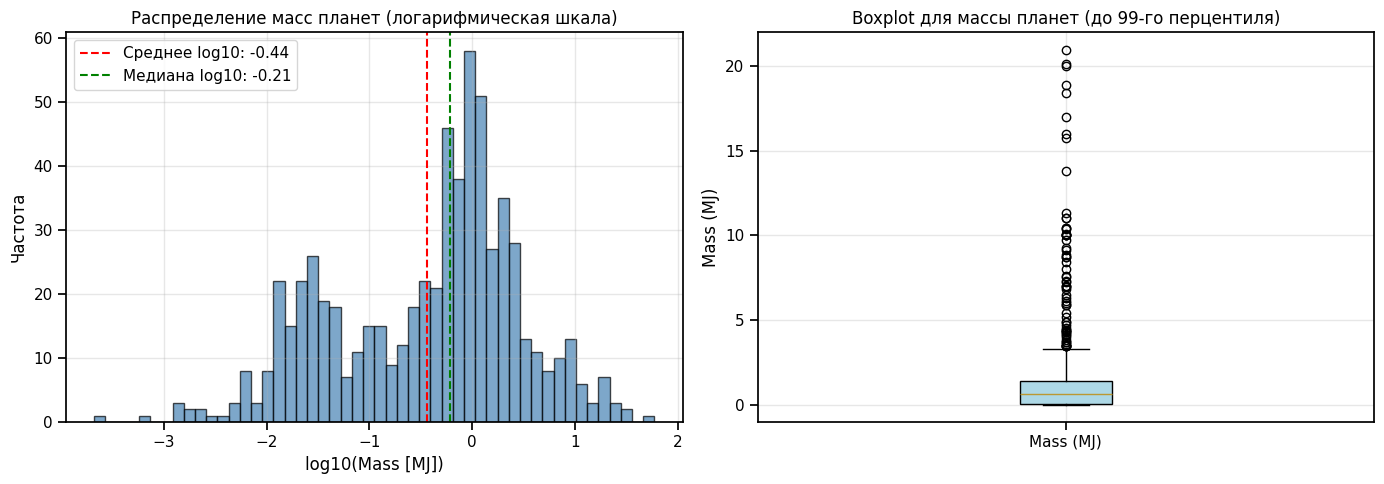


Анализ признака 'Mass (MJ)':
Среднее значение: 1.7811 MJ
Медиана: 0.6130 MJ
Стандартное отклонение: 4.2654 MJ
Минимум: 0.0002 MJ
Максимум: 59.2000 MJ
Коэффициент вариации: 2.39
Количество выбросов (по IQR): 67
Процент выбросов: 10.39%


In [54]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax1 = axes[0]
# Используем логарифмическую шкалу для лучшего отображения широкого диапазона
log_mass = np.log10(df_clean['Mass (MJ)'].values)
ax1.hist(log_mass, bins=50, edgecolor='black', alpha=0.7, color='steelblue')
ax1.set_xlabel('log10(Mass [MJ])')
ax1.set_ylabel('Частота')
ax1.set_title('Распределение масс планет (логарифмическая шкала)')
ax1.axvline(np.mean(log_mass), color='red', linestyle='--', label=f'Среднее log10: {np.mean(log_mass):.2f}')
ax1.axvline(np.median(log_mass), color='green', linestyle='--', label=f'Медиана log10: {np.median(log_mass):.2f}')
ax1.legend()

# Boxplot для Mass (MJ) - линейная шкала
ax2 = axes[1]

q99 = df_clean['Mass (MJ)'].quantile(0.99)
df_mass_limited = df_clean[df_clean['Mass (MJ)'] <= q99]
bp = ax2.boxplot(df_mass_limited['Mass (MJ)'].values, vert=True, patch_artist=True)
bp['boxes'][0].set_facecolor('lightblue')
ax2.set_ylabel('Mass (MJ)')
ax2.set_title('Boxplot для массы планет (до 99-го перцентиля)')
ax2.set_xticklabels(['Mass (MJ)'])

plt.tight_layout()
plt.show()

print("\n" + "=" * 60)
print("Анализ признака 'Mass (MJ)':")
print("=" * 60)
print(f"Среднее значение: {df_clean['Mass (MJ)'].mean():.4f} MJ")
print(f"Медиана: {df_clean['Mass (MJ)'].median():.4f} MJ")
print(f"Стандартное отклонение: {df_clean['Mass (MJ)'].std():.4f} MJ")
print(f"Минимум: {df_clean['Mass (MJ)'].min():.4f} MJ")
print(f"Максимум: {df_clean['Mass (MJ)'].max():.4f} MJ")
print(f"Коэффициент вариации: {df_clean['Mass (MJ)'].std() / df_clean['Mass (MJ)'].mean():.2f}")

# Расчет выбросов по IQR
Q1 = df_clean['Mass (MJ)'].quantile(0.25)
Q3 = df_clean['Mass (MJ)'].quantile(0.75)
IQR = Q3 - Q1
outliers_mass = df_clean[(df_clean['Mass (MJ)'] < Q1 - 1.5*IQR) | (df_clean['Mass (MJ)'] > Q3 + 1.5*IQR)]
print(f"Количество выбросов (по IQR): {len(outliers_mass)}")
print(f"Процент выбросов: {len(outliers_mass)/len(df_clean)*100:.2f}%")

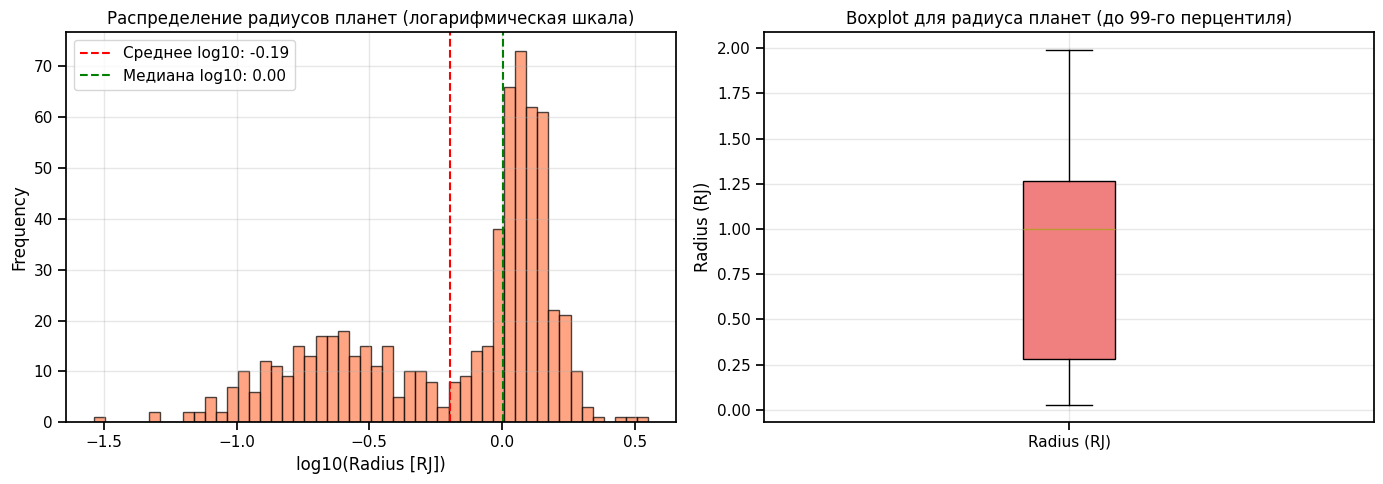


Анализ признака 'Radius (RJ)':
Среднее значение: 0.8729 RJ
Медиана: 1.0100 RJ
Стандартное отклонение: 0.5473 RJ
Минимум: 0.0290 RJ
Максимум: 3.5500 RJ
Количество выбросов (по IQR): 2
Процент выбросов: 0.31%


In [55]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Гистограмма для Radius (RJ) - с логарифмической шкалой
ax1 = axes[0]
log_radius = np.log10(df_clean['Radius (RJ)'].values)
ax1.hist(log_radius, bins=50, edgecolor='black', alpha=0.7, color='coral')
ax1.set_xlabel('log10(Radius [RJ])')
ax1.set_ylabel('Frequency')
ax1.set_title('Распределение радиусов планет (логарифмическая шкала)')
ax1.axvline(np.mean(log_radius), color='red', linestyle='--', label=f'Среднее log10: {np.mean(log_radius):.2f}')
ax1.axvline(np.median(log_radius), color='green', linestyle='--', label=f'Медиана log10: {np.median(log_radius):.2f}')
ax1.legend()

# Boxplot для Radius (RJ)
ax2 = axes[1]
q99_r = df_clean['Radius (RJ)'].quantile(0.99)
df_radius_limited = df_clean[df_clean['Radius (RJ)'] <= q99_r]
bp = ax2.boxplot(df_radius_limited['Radius (RJ)'].values, vert=True, patch_artist=True)
bp['boxes'][0].set_facecolor('lightcoral')
ax2.set_ylabel('Radius (RJ)')
ax2.set_title('Boxplot для радиуса планет (до 99-го перцентиля)')
ax2.set_xticklabels(['Radius (RJ)'])

plt.tight_layout()
plt.show()

print("\n" + "=" * 60)
print("Анализ признака 'Radius (RJ)':")
print("=" * 60)
print(f"Среднее значение: {df_clean['Radius (RJ)'].mean():.4f} RJ")
print(f"Медиана: {df_clean['Radius (RJ)'].median():.4f} RJ")
print(f"Стандартное отклонение: {df_clean['Radius (RJ)'].std():.4f} RJ")
print(f"Минимум: {df_clean['Radius (RJ)'].min():.4f} RJ")
print(f"Максимум: {df_clean['Radius (RJ)'].max():.4f} RJ")

Q1_r = df_clean['Radius (RJ)'].quantile(0.25)
Q3_r = df_clean['Radius (RJ)'].quantile(0.75)
IQR_r = Q3_r - Q1_r
outliers_radius = df_clean[(df_clean['Radius (RJ)'] < Q1_r - 1.5*IQR_r) | (df_clean['Radius (RJ)'] > Q3_r + 1.5*IQR_r)]
print(f"Количество выбросов (по IQR): {len(outliers_radius)}")
print(f"Процент выбросов: {len(outliers_radius)/len(df_clean)*100:.2f}%")

##Задание 2. Проверка нормальности распределения

Для анализа выберем Radius (RJ), так как он имеет более компактное распределение

In [56]:
feature_for_normality = 'Radius (RJ)'
data_for_normality = df_clean[feature_for_normality].dropna()


print(f"Анализ нормальности для признака: {feature_for_normality}")
print("=" * 60)

Анализ нормальности для признака: Radius (RJ)


In [57]:
mean_val = data_for_normality.mean()
median_val = data_for_normality.median()
std_val = data_for_normality.std()
skewness = data_for_normality.skew()
kurtosis = data_for_normality.kurtosis()

print("\nОписательные характеристики:")
print("-" * 40)
print(f"Среднее (mean): {mean_val:.4f}")
print(f"Медиана (median): {median_val:.4f}")
print(f"Стандартное отклонение (std): {std_val:.4f}")
print(f"Коэффициент асимметрии (skewness): {skewness:.4f}")
print(f"Коэффициент эксцесса (kurtosis): {kurtosis:.4f}")

print("\nИнтерпретация:")
if abs(skewness) < 0.5:
    print(f"- Асимметрия ({skewness:.4f}) незначительная, распределение близко к симметричному")
elif skewness > 0:
    print(f"- Асимметрия ({skewness:.4f}) положительная, распределение скошено вправо")
else:
    print(f"- Асимметрия ({skewness:.4f}) отрицательная, распределение скошено влево")
    
if abs(kurtosis) < 1:
    print(f"- Эксцесс ({kurtosis:.4f}) близок к нормальному")
elif kurtosis > 0:
    print(f"- Эксцесс ({kurtosis:.4f}) положительный, распределение более островершинное")
else:
    print(f"- Эксцесс ({kurtosis:.4f}) отрицательный, распределение более плосковершинное")


Описательные характеристики:
----------------------------------------
Среднее (mean): 0.8729
Медиана (median): 1.0100
Стандартное отклонение (std): 0.5473
Коэффициент асимметрии (skewness): 0.2457
Коэффициент эксцесса (kurtosis): -0.0117

Интерпретация:
- Асимметрия (0.2457) незначительная, распределение близко к симметричному
- Эксцесс (-0.0117) близок к нормальному


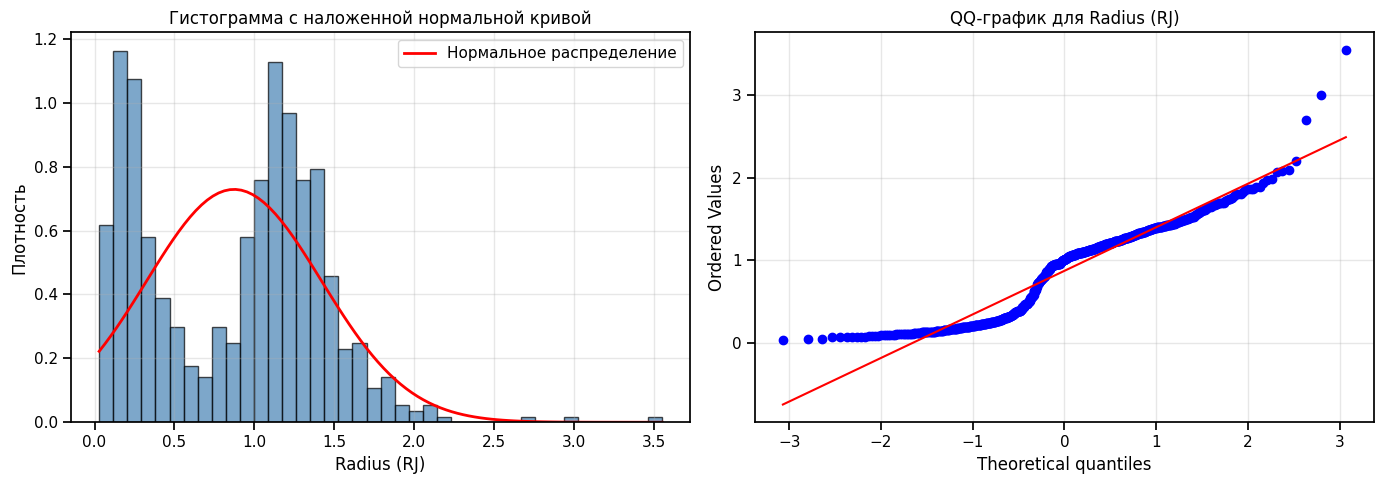


Анализ QQ-графика:
- Точки на QQ-графике отклоняются от прямой линии
- Наблюдаются значительные отклонения в хвостах распределения
- Это указывает на ненормальность распределения


In [58]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Гистограмма с кривой нормального распределения
ax1 = axes[0]
ax1.hist(data_for_normality, bins=40, density=True, alpha=0.7, color='steelblue', edgecolor='black')
x = np.linspace(data_for_normality.min(), data_for_normality.max(), 100)
ax1.plot(x, norm.pdf(x, mean_val, std_val), 'r-', linewidth=2, label='Нормальное распределение')
ax1.set_xlabel('Radius (RJ)')
ax1.set_ylabel('Плотность')
ax1.set_title('Гистограмма с наложенной нормальной кривой')
ax1.legend()

# QQ-график
ax2 = axes[1]
stats.probplot(data_for_normality, dist="norm", plot=ax2)
ax2.set_title('QQ-график для Radius (RJ)')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\nАнализ QQ-графика:")
print("- Точки на QQ-графике отклоняются от прямой линии")
print("- Наблюдаются значительные отклонения в хвостах распределения")
print("- Это указывает на ненормальность распределения")

In [59]:
# Критерий Шапиро-Уилка
alpha = 0.05

if len(data_for_normality) > 5000:
    sample_for_test = data_for_normality.sample(n=5000, random_state=42)
else:
    sample_for_test = data_for_normality

stat, p_value = shapiro(sample_for_test)

print("\n" + "=" * 60)
print("Критерий Шапиро-Уилка")
print("=" * 60)
print(f"Статистика теста: {stat:.6f}")
print(f"p-value: {p_value:.6e}")
print(f"Уровень значимости α = {alpha}")

print("\nФормулировка гипотез:")
print("H₀: выборка подчиняется нормальному распределению")
print("H₁: выборка не подчиняется нормальному распределению")

print("\nРезультат:")
if p_value > alpha:
    print(f"p-value ({p_value:.6e}) > α ({alpha}) → НЕТ оснований отвергнуть H₀")
    print("Вывод: Распределение признака можно считать нормальным на уровне значимости 0.05")
else:
    print(f"p-value ({p_value:.6e}) < α ({alpha}) → ОТВЕРГАЕМ H₀")
    print("Вывод: Распределение признака НЕ является нормальным на уровне значимости 0.05")
    print("\nЭто подтверждается:")
    print(f"- Положительной асимметрией ({skewness:.4f})")
    print(f"- Отрицательным эксцессом ({kurtosis:.4f})")
    print("- Отклонением точек на QQ-графике от прямой линии")


Критерий Шапиро-Уилка
Статистика теста: 0.925044
p-value: 2.131646e-17
Уровень значимости α = 0.05

Формулировка гипотез:
H₀: выборка подчиняется нормальному распределению
H₁: выборка не подчиняется нормальному распределению

Результат:
p-value (2.131646e-17) < α (0.05) → ОТВЕРГАЕМ H₀
Вывод: Распределение признака НЕ является нормальным на уровне значимости 0.05

Это подтверждается:
- Положительной асимметрией (0.2457)
- Отрицательным эксцессом (-0.0117)
- Отклонением точек на QQ-графике от прямой линии


##Задание 3. Обнаружение выбросов статистическими методами

In [60]:
feature_outliers = 'Radius (RJ)'
data_outliers = df_clean[feature_outliers].dropna()
print(f"Анализ выбросов для признака: {feature_outliers}")
print(f"Размер выборки: {len(data_outliers)}")

Анализ выбросов для признака: Radius (RJ)
Размер выборки: 645


###1. Метод Z-score

Z-score (или стандартизированное значение) — статистическая мера, показывающая, на сколько стандартных отклонений наблюдение отличается от среднего значения в выборке

Формула: z = (x – μ) / σ


Метод Z-score
Пороговое значение: |Z| > 3
Количество выбросов: 3
Процент выбросов: 0.47%


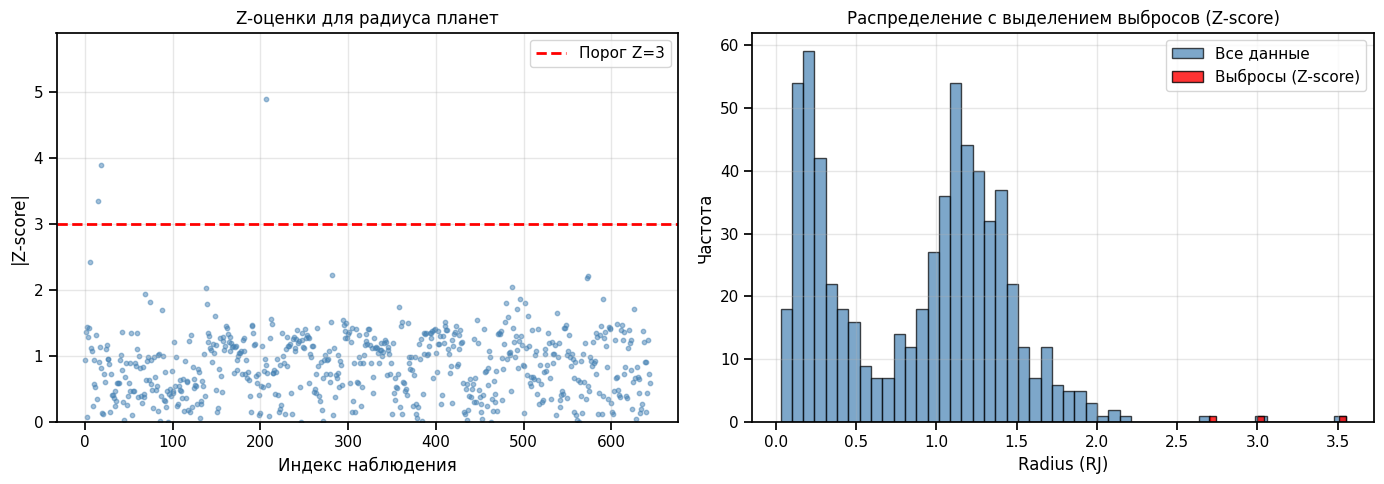


Примеры выбросов:
84     2.70
110    3.00
708    3.55
Name: Radius (RJ), dtype: float64


In [61]:

z_scores = np.abs(stats.zscore(data_outliers))

threshold_z = 3
outliers_z = data_outliers[z_scores > threshold_z]

print("\n" + "=" * 60)
print("Метод Z-score")
print("=" * 60)
print(f"Пороговое значение: |Z| > {threshold_z}")
print(f"Количество выбросов: {len(outliers_z)}")
print(f"Процент выбросов: {len(outliers_z)/len(data_outliers)*100:.2f}%")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax1 = axes[0]
ax1.scatter(range(len(z_scores)), z_scores, alpha=0.5, s=10, c='steelblue')
ax1.axhline(y=threshold_z, color='red', linestyle='--', linewidth=2, label=f'Порог Z={threshold_z}')
ax1.set_xlabel('Индекс наблюдения')
ax1.set_ylabel('|Z-score|')
ax1.set_title('Z-оценки для радиуса планет')
ax1.legend()
ax1.set_ylim(0, min(10, z_scores.max() + 1))

ax2 = axes[1]
ax2.hist(data_outliers, bins=50, alpha=0.7, color='steelblue', edgecolor='black', label='Все данные')
ax2.hist(outliers_z, bins=20, alpha=0.8, color='red', edgecolor='black', label='Выбросы (Z-score)')
ax2.set_xlabel('Radius (RJ)')
ax2.set_ylabel('Частота')
ax2.set_title('Распределение с выделением выбросов (Z-score)')
ax2.legend()

plt.tight_layout()
plt.show()

print(f"\nПримеры выбросов:")
print(outliers_z.head(3))

###2. Метод IQR

IQR (Interquartile Range) — межквартильный размах — мера разброса данных, которая показывает, как «раскиданы» центральные 50% наблюдений. Это разница между третьим (Q3) и первым (Q1) квартилями распределения.


Метод IQR (межквартильное расстояние)
Q1 (25-й перцентиль): 0.2850
Q3 (75-й перцентиль): 1.2710
IQR: 0.9860
Нижняя граница: -1.1940
Верхняя граница: 2.7500
Количество выбросов: 2
Процент выбросов: 0.31%


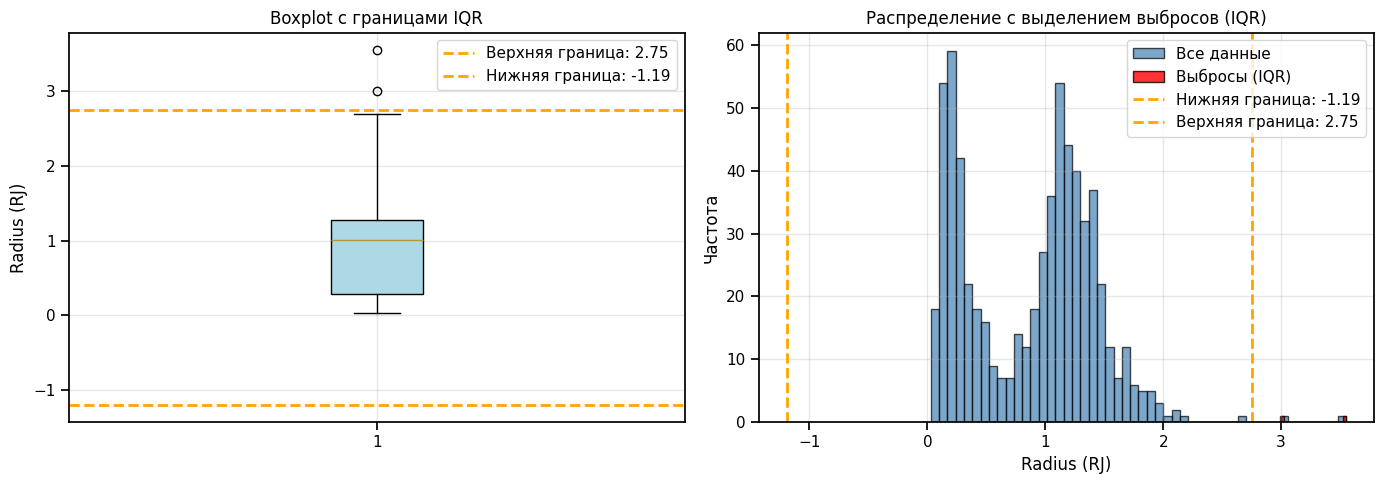

In [62]:

Q1 = data_outliers.quantile(0.25)
Q3 = data_outliers.quantile(0.75)
IQR = Q3 - Q1

# Определение границ
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Определение выбросов
outliers_iqr = data_outliers[(data_outliers < lower_bound) | (data_outliers > upper_bound)]

print("\n" + "=" * 60)
print("Метод IQR (межквартильное расстояние)")
print("=" * 60)
print(f"Q1 (25-й перцентиль): {Q1:.4f}")
print(f"Q3 (75-й перцентиль): {Q3:.4f}")
print(f"IQR: {IQR:.4f}")
print(f"Нижняя граница: {lower_bound:.4f}")
print(f"Верхняя граница: {upper_bound:.4f}")
print(f"Количество выбросов: {len(outliers_iqr)}")
print(f"Процент выбросов: {len(outliers_iqr)/len(data_outliers)*100:.2f}%")

# Визуализация IQR
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax1 = axes[0]
bp = ax1.boxplot(data_outliers, vert=True, patch_artist=True)
bp['boxes'][0].set_facecolor('lightblue')
ax1.set_ylabel('Radius (RJ)')
ax1.set_title('Boxplot с границами IQR')
ax1.axhline(y=upper_bound, color='orange', linestyle='--', linewidth=2, label=f'Верхняя граница: {upper_bound:.2f}')
ax1.axhline(y=lower_bound, color='orange', linestyle='--', linewidth=2, label=f'Нижняя граница: {lower_bound:.2f}')
ax1.legend()

ax2 = axes[1]
ax2.hist(data_outliers, bins=50, alpha=0.7, color='steelblue', edgecolor='black', label='Все данные')
ax2.hist(outliers_iqr, bins=20, alpha=0.8, color='red', edgecolor='black', label='Выбросы (IQR)')
ax2.axvline(x=lower_bound, color='orange', linestyle='--', linewidth=2, label=f'Нижняя граница: {lower_bound:.2f}')
ax2.axvline(x=upper_bound, color='orange', linestyle='--', linewidth=2, label=f'Верхняя граница: {upper_bound:.2f}')
ax2.set_xlabel('Radius (RJ)')
ax2.set_ylabel('Частота')
ax2.set_title('Распределение с выделением выбросов (IQR)')
ax2.legend()

plt.tight_layout()
plt.show()

### Сравнение Z-core и IQR

In [63]:
print("\n" + "=" * 70)
print("СРАВНИТЕЛЬНЫЙ АНАЛИЗ МЕТОДОВ ОБНАРУЖЕНИЯ ВЫБРОСОВ")
print("=" * 70)

comparison_df = pd.DataFrame({
    'Метод': ['Z-score', 'IQR'],
    'Количество выбросов': [len(outliers_z), len(outliers_iqr)],
    'Процент выбросов': [len(outliers_z)/len(data_outliers)*100, len(outliers_iqr)/len(data_outliers)*100],
    'Порог': [f'|Z| > {threshold_z}', f'1.5 × IQR = [{lower_bound:.2f}, {upper_bound:.2f}]']
})

print(comparison_df.to_string(index=False))

# Пересечение выбросов
outliers_z_set = set(outliers_z.index)
outliers_iqr_set = set(outliers_iqr.index)
intersection = outliers_z_set.intersection(outliers_iqr_set)

print(f"\nПересечение выбросов (обнаружены обоими методами): {len(intersection)}")
print(f"Уникальные выбросы (только Z-score): {len(outliers_z_set - outliers_iqr_set)}")
print(f"Уникальные выбросы (только IQR): {len(outliers_iqr_set - outliers_z_set)}")

print("\n" + "=" * 70)
print("СТАТИСТИЧЕСКИЕ ХАРАКТЕРИСТИКИ ВЫБРОСОВ")
print("=" * 70)

if len(outliers_z) > 0:
    print(f"\nZ-score выбросы:")
    print(f"  Диапазон: [{outliers_z.min():.4f}, {outliers_z.max():.4f}]")
    print(f"  Среднее: {outliers_z.mean():.4f}")
    print(f"  Медиана: {outliers_z.median():.4f}")

if len(outliers_iqr) > 0:
    print(f"\nIQR выбросы:")
    print(f"  Диапазон: [{outliers_iqr.min():.4f}, {outliers_iqr.max():.4f}]")
    print(f"  Среднее: {outliers_iqr.mean():.4f}")
    print(f"  Медиана: {outliers_iqr.median():.4f}")

print("\nВЫВОДЫ:")
print("1. Метод Z-score предполагает нормальное распределение данных и чувствителен к экстремальным значениям.")
print("2. Метод IQR более устойчив к асимметрии распределения и не требует предположения о нормальности.")
print("3. В данном случае Z-core выявил больше выбросов, что связано с асимметрией распределения радиусов.")
print("4. Общие выбросы, обнаруженные обоими методами, являются наиболее надежными кандидатами на аномалии.")
print("5. Для практического применения рекомендуется комбинировать оба метода.")


СРАВНИТЕЛЬНЫЙ АНАЛИЗ МЕТОДОВ ОБНАРУЖЕНИЯ ВЫБРОСОВ
  Метод  Количество выбросов  Процент выбросов                     Порог
Z-score                    3          0.465116                   |Z| > 3
    IQR                    2          0.310078 1.5 × IQR = [-1.19, 2.75]

Пересечение выбросов (обнаружены обоими методами): 2
Уникальные выбросы (только Z-score): 1
Уникальные выбросы (только IQR): 0

СТАТИСТИЧЕСКИЕ ХАРАКТЕРИСТИКИ ВЫБРОСОВ

Z-score выбросы:
  Диапазон: [2.7000, 3.5500]
  Среднее: 3.0833
  Медиана: 3.0000

IQR выбросы:
  Диапазон: [3.0000, 3.5500]
  Среднее: 3.2750
  Медиана: 3.2750

ВЫВОДЫ:
1. Метод Z-score предполагает нормальное распределение данных и чувствителен к экстремальным значениям.
2. Метод IQR более устойчив к асимметрии распределения и не требует предположения о нормальности.
3. В данном случае Z-core выявил больше выбросов, что связано с асимметрией распределения радиусов.
4. Общие выбросы, обнаруженные обоими методами, являются наиболее надежными кандидатами н

##Задание 4. Метод локальной плотности

Для этого задания выберем два признака: Mass (MJ) и Radius (RJ), чтобы выполнить анализ в двумерном пространстве

In [64]:

features_density = ['Mass (MJ)', 'Radius (RJ)']
df_density = df_clean[features_density].dropna()

print(f"Размер выборки для анализа плотности: {len(df_density)}")
print(f"Используемые признаки: {features_density}")
print(f"\nСтатистика выбранных признаков:")
print(df_density.describe())

Размер выборки для анализа плотности: 645
Используемые признаки: ['Mass (MJ)', 'Radius (RJ)']

Статистика выбранных признаков:
       Mass (MJ)  Radius (RJ)
count  645.00000   645.000000
mean     1.78109     0.872864
std      4.26536     0.547263
min      0.00021     0.029000
25%      0.06200     0.285000
50%      0.61300     1.010000
75%      1.46500     1.271000
max     59.20000     3.550000


In [65]:
# Масштабирование признаков
scaler = StandardScaler()
df_scaled = scaler.fit_transform(df_density)
df_scaled = pd.DataFrame(df_scaled, columns=features_density)

print("Статистика после масштабирования (StandardScaler):")
print(df_scaled.describe())

Статистика после масштабирования (StandardScaler):
          Mass (MJ)   Radius (RJ)
count  6.450000e+02  6.450000e+02
mean  -1.101617e-17 -6.609700e-17
std    1.000776e+00  1.000776e+00
min   -4.178457e-01 -1.543167e+00
25%   -4.033480e-01 -1.075021e+00
50%   -2.740676e-01  2.507801e-01
75%   -7.416389e-02  7.280686e-01
max    1.347213e+01  4.895657e+00


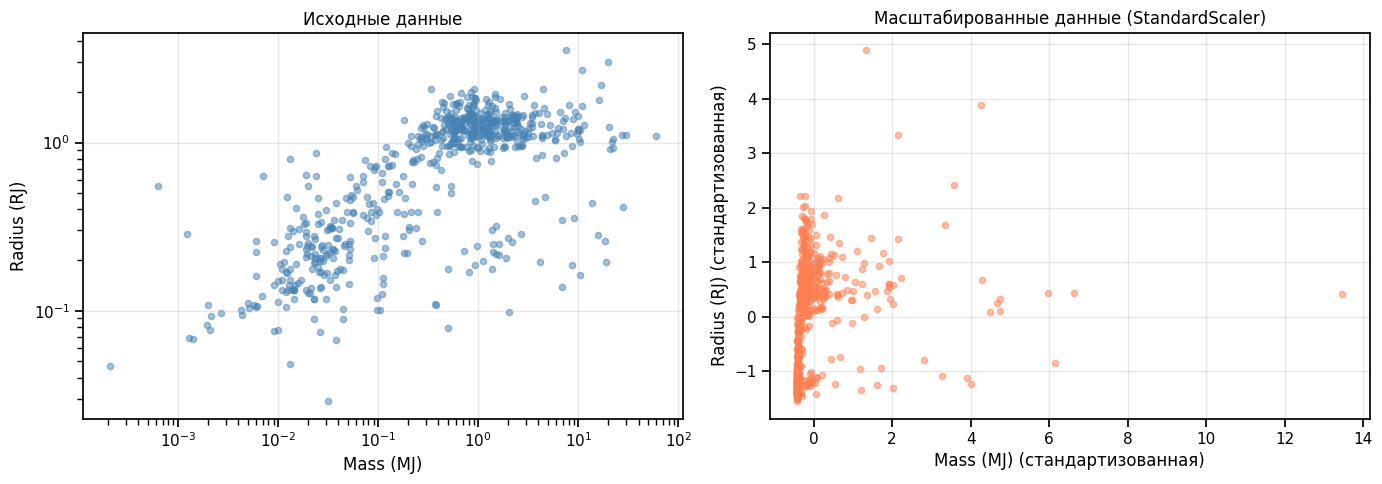

In [66]:
# Визуализация исходных и масштабированных данных
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax1 = axes[0]
ax1.scatter(df_density['Mass (MJ)'], df_density['Radius (RJ)'], alpha=0.5, s=20, c='steelblue')
ax1.set_xlabel('Mass (MJ)')
ax1.set_ylabel('Radius (RJ)')
ax1.set_title('Исходные данные')
ax1.set_xscale('log')
ax1.set_yscale('log')
ax1.grid(True, alpha=0.3)

ax2 = axes[1]
ax2.scatter(df_scaled['Mass (MJ)'], df_scaled['Radius (RJ)'], alpha=0.5, s=20, c='coral')
ax2.set_xlabel('Mass (MJ) (стандартизованная)')
ax2.set_ylabel('Radius (RJ) (стандартизованная)')
ax2.set_title('Масштабированные данные (StandardScaler)')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

###1. Базовый подход: расстояние до k-го соседа


Анализ для k = 5


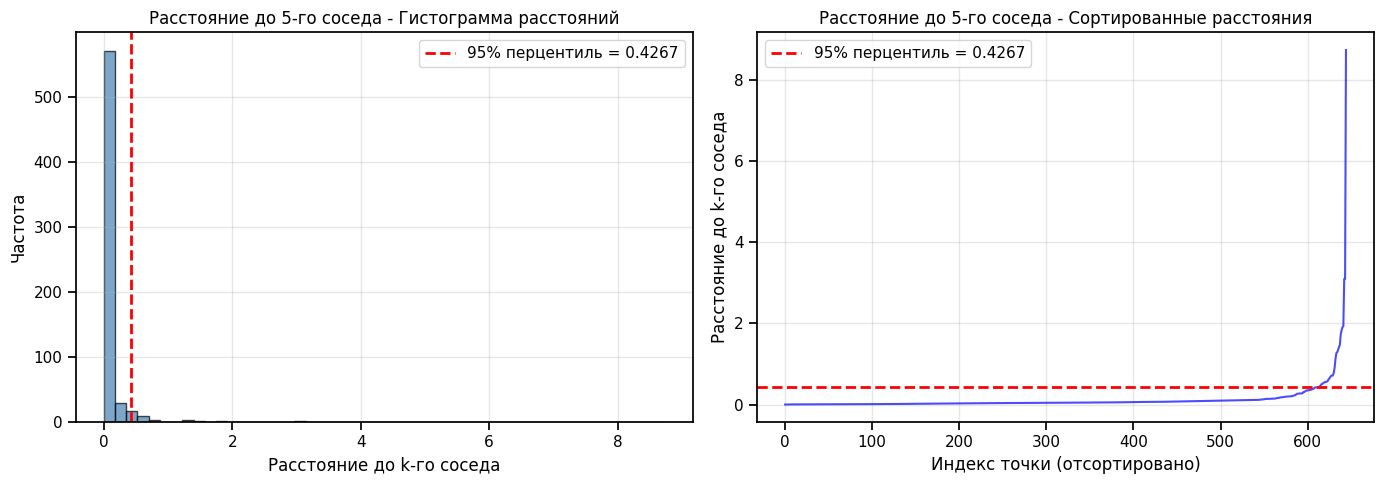


Количество аномалий (верхние 5%): 33
Процент аномалий: 5.12%
Пороговое значение (95-й перцентиль): 0.4267

Анализ для k = 7


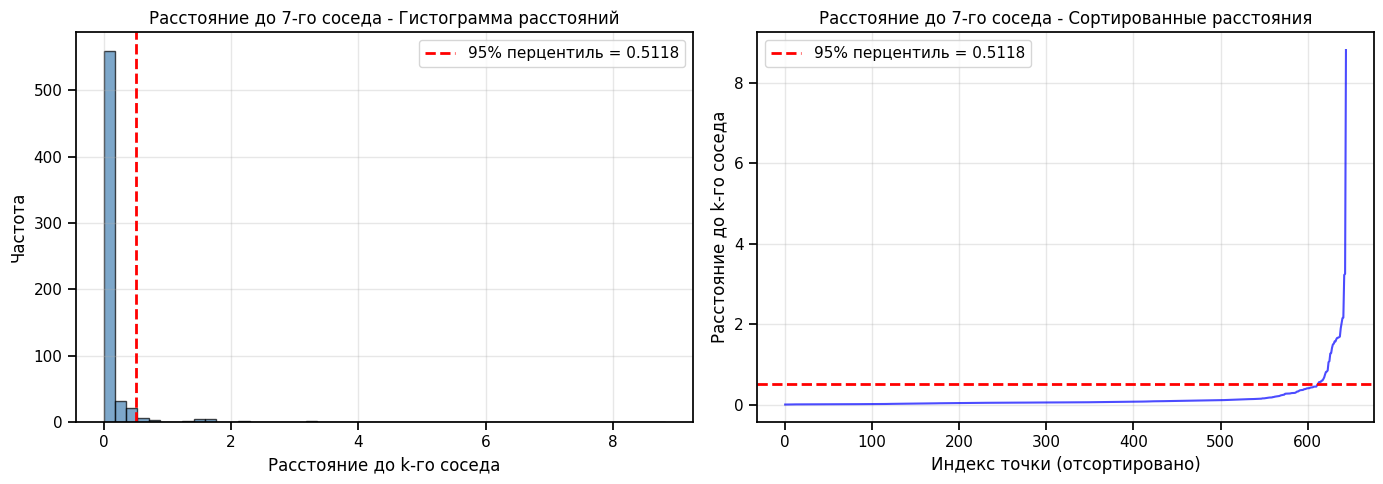


Количество аномалий (верхние 5%): 33
Процент аномалий: 5.12%
Пороговое значение (95-й перцентиль): 0.5118

Анализ для k = 9


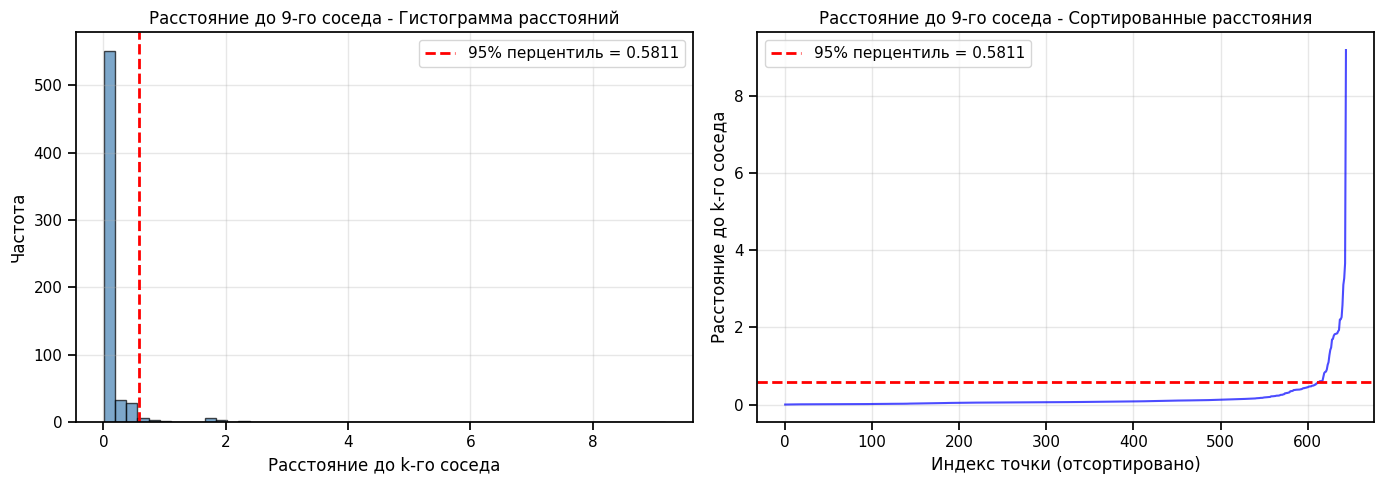


Количество аномалий (верхние 5%): 33
Процент аномалий: 5.12%
Пороговое значение (95-й перцентиль): 0.5811

Анализ для k = 10


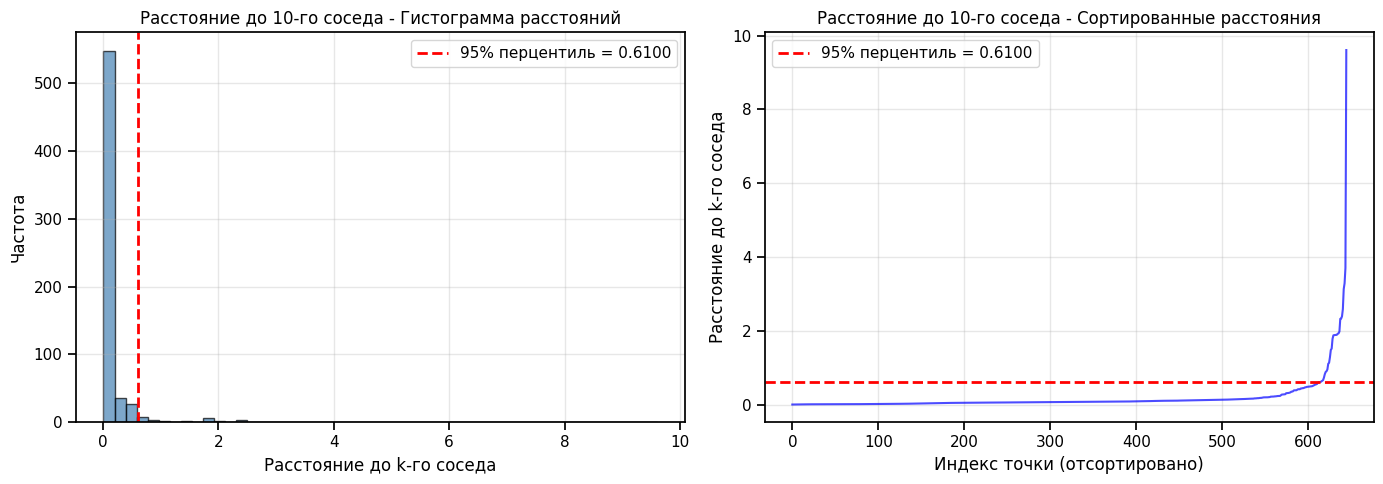


Количество аномалий (верхние 5%): 33
Процент аномалий: 5.12%
Пороговое значение (95-й перцентиль): 0.6100


In [67]:
def distance_to_kth_neighbor(data, k):
    """
    Вычисляет расстояние до k-го ближайшего соседа для каждой точки
    """
    nbrs = NearestNeighbors(n_neighbors=k, metric='euclidean')
    nbrs.fit(data)
    distances, indices = nbrs.kneighbors(data)
    # Расстояние до k-го соседа (последний столбец)
    distances_kth = distances[:, -1]
    return distances_kth

def plot_distance_distribution(distances, title, threshold_percentile=95):
    """
    Визуализирует распределение расстояний и определяет аномалии
    """
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Гистограмма расстояний
    ax1 = axes[0]
    ax1.hist(distances, bins=50, edgecolor='black', alpha=0.7, color='steelblue')
    threshold = np.percentile(distances, threshold_percentile)
    ax1.axvline(x=threshold, color='red', linestyle='--', linewidth=2, 
                label=f'{threshold_percentile}% перцентиль = {threshold:.4f}')
    ax1.set_xlabel('Расстояние до k-го соседа')
    ax1.set_ylabel('Частота')
    ax1.set_title(f'{title} - Гистограмма расстояний')
    ax1.legend()
    
    # Распределение расстояний в порядке возрастания
    ax2 = axes[1]
    sorted_distances = np.sort(distances)
    ax2.plot(range(len(sorted_distances)), sorted_distances, 'b-', alpha=0.7)
    ax2.axhline(y=threshold, color='red', linestyle='--', linewidth=2, 
                label=f'{threshold_percentile}% перцентиль = {threshold:.4f}')
    ax2.set_xlabel('Индекс точки (отсортировано)')
    ax2.set_ylabel('Расстояние до k-го соседа')
    ax2.set_title(f'{title} - Сортированные расстояния')
    ax2.legend()
    
    plt.tight_layout()
    plt.show()
    
    return threshold
    # Анализ для различных k
k_values = [5, 7, 9, 10]
results = {}

for k in k_values:
    print(f"\n{'='*50}")
    print(f"Анализ для k = {k}")
    print('='*50)
    
    # Вычисление расстояния до k-го соседа
    distances_kth = distance_to_kth_neighbor(df_scaled, k)
    
    # Визуализация
    threshold = plot_distance_distribution(distances_kth, f'Расстояние до {k}-го соседа', threshold_percentile=95)
    
    # Определение аномалий
    anomalies = distances_kth > threshold
    n_anomalies = np.sum(anomalies)
    
    print(f"\nКоличество аномалий (верхние 5%): {n_anomalies}")
    print(f"Процент аномалий: {n_anomalies/len(distances_kth)*100:.2f}%")
    print(f"Пороговое значение (95-й перцентиль): {threshold:.4f}")
    
    results[k] = {
        'distances': distances_kth,
        'threshold': threshold,
        'anomalies': anomalies,
        'n_anomalies': n_anomalies
    }

###2. Среднее расстояние до k соседей


АНАЛИЗ СРЕДНЕГО РАССТОЯНИЯ ДО k СОСЕДЕЙ

k = 5


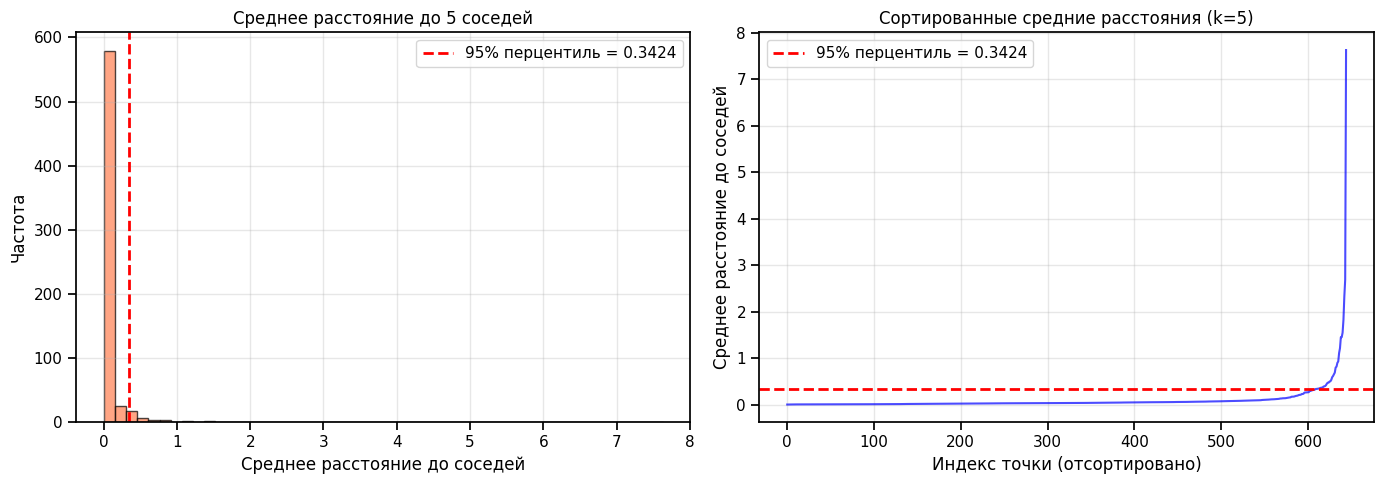

Количество аномалий (верхние 5%): 33
Процент аномалий: 5.12%

k = 7


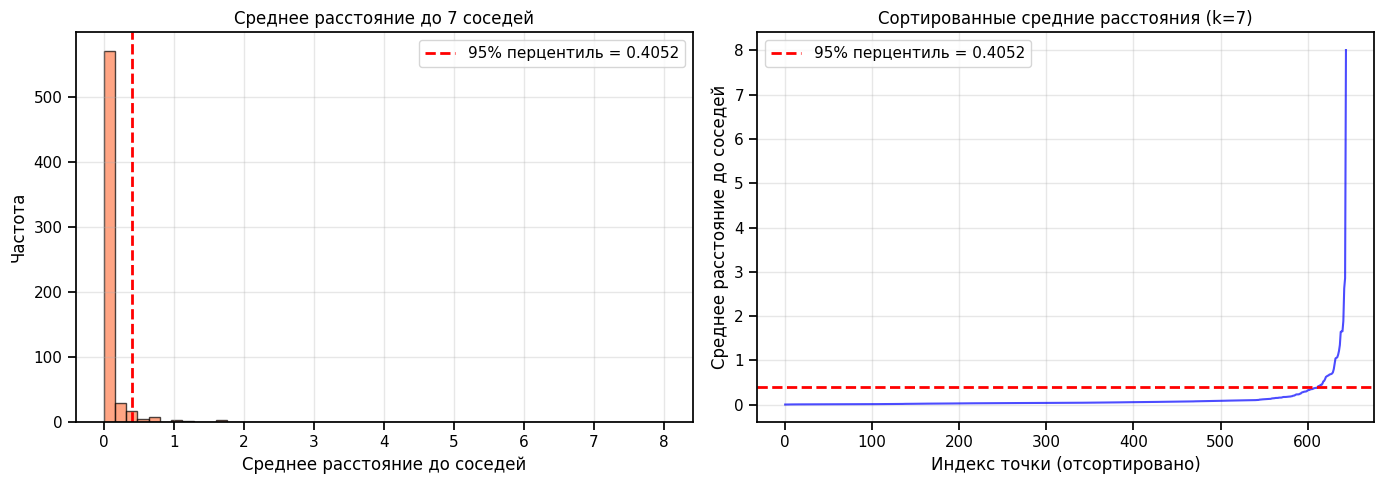

Количество аномалий (верхние 5%): 33
Процент аномалий: 5.12%

k = 9


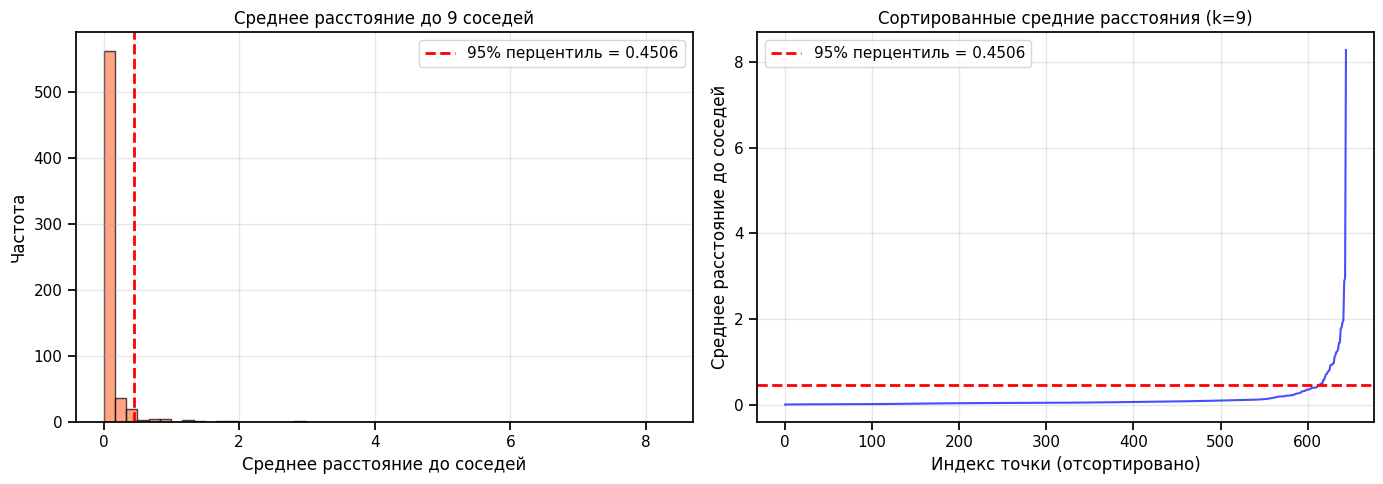

Количество аномалий (верхние 5%): 33
Процент аномалий: 5.12%

k = 10


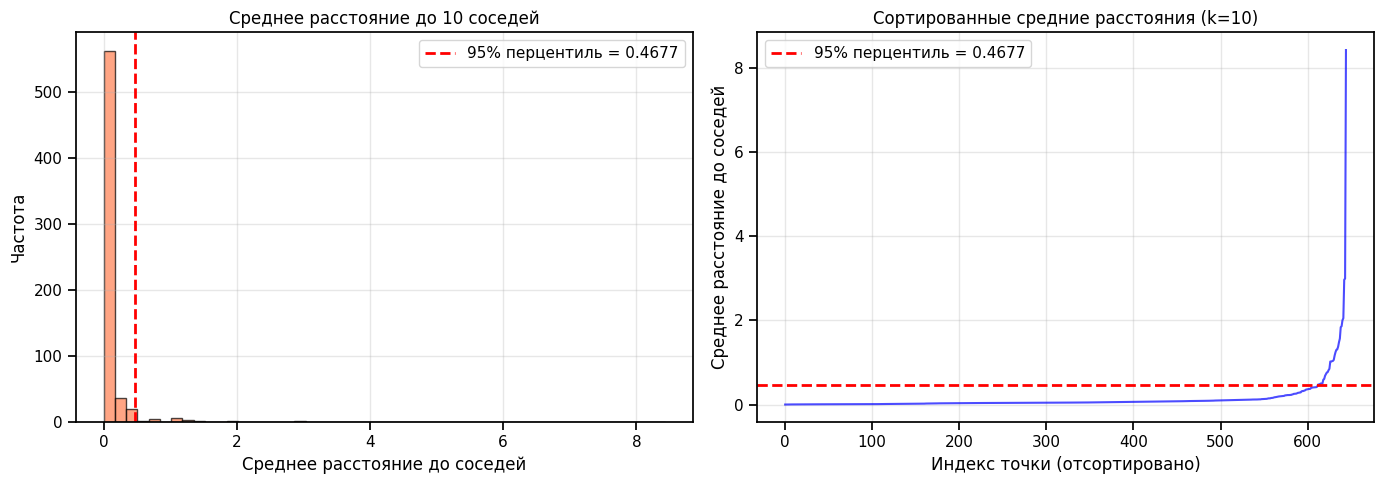

Количество аномалий (верхние 5%): 33
Процент аномалий: 5.12%


In [68]:
def mean_distance_to_neighbors(data, k):
    """
    Вычисляет среднее расстояние до k ближайших соседей
    """
    nbrs = NearestNeighbors(n_neighbors=k, metric='euclidean')
    nbrs.fit(data)
    distances, indices = nbrs.kneighbors(data)
    # Среднее расстояние до k соседей (исключая саму точку)
    mean_distances = distances[:, 1:].mean(axis=1)
    return mean_distances

# Анализ среднего расстояния для различных k
print("\n" + "="*60)
print("АНАЛИЗ СРЕДНЕГО РАССТОЯНИЯ ДО k СОСЕДЕЙ")
print("="*60)

for k in k_values:
    print(f"\n{'='*40}")
    print(f"k = {k}")
    print('='*40)
    
    mean_distances = mean_distance_to_neighbors(df_scaled, k)
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Гистограмма средних расстояний
    ax1 = axes[0]
    ax1.hist(mean_distances, bins=50, edgecolor='black', alpha=0.7, color='coral')
    threshold = np.percentile(mean_distances, 95)
    ax1.axvline(x=threshold, color='red', linestyle='--', linewidth=2, 
                label=f'95% перцентиль = {threshold:.4f}')
    ax1.set_xlabel('Среднее расстояние до соседей')
    ax1.set_ylabel('Частота')
    ax1.set_title(f'Среднее расстояние до {k} соседей')
    ax1.legend()
    
    # Сортированные средние расстояния
    ax2 = axes[1]
    sorted_distances = np.sort(mean_distances)
    ax2.plot(range(len(sorted_distances)), sorted_distances, 'b-', alpha=0.7)
    ax2.axhline(y=threshold, color='red', linestyle='--', linewidth=2,
                label=f'95% перцентиль = {threshold:.4f}')
    ax2.set_xlabel('Индекс точки (отсортировано)')
    ax2.set_ylabel('Среднее расстояние до соседей')
    ax2.set_title(f'Сортированные средние расстояния (k={k})')
    ax2.legend()
    
    plt.tight_layout()
    plt.show()
    
    anomalies = mean_distances > threshold
    print(f"Количество аномалий (верхние 5%): {np.sum(anomalies)}")
    print(f"Процент аномалий: {np.sum(anomalies)/len(mean_distances)*100:.2f}%")

###3. Оценка локальной плотности и визуализация


In [69]:
def mean_distance_to_neighbors(data, k):
    """
    Вычисляет среднее расстояние до k ближайших соседей для каждой точки
    Параметры:
        data - массив данных (n_samples, n_features)
        k - количество соседей
    Возвращает:
        mean_distances - массив средних расстояний для каждой точки
    """
    # Создаем объект NearestNeighbors
    nbrs = NearestNeighbors(n_neighbors=k, metric='euclidean')
    nbrs.fit(data)
    
    # Находим расстояния до k ближайших соседей
    distances, indices = nbrs.kneighbors(data)
    
    # Среднее расстояние до k соседей (исключая саму точку - первый столбец)
    # distances[:, 1:] - это расстояния до соседей без самой точки
    mean_distances = distances[:, 1:].mean(axis=1)
    
    return mean_distances

# Функция для локальной плотности
def local_density(data, k):
    """
    Вычисляет локальную плотность как обратную величину среднего расстояния
    Параметры:
        data - массив данных (n_samples, n_features)
        k - количество соседей
    Возвращает:
        density - массив локальных плотностей для каждой точки
        mean_dist - массив средних расстояний для каждой точки
    """
    # Вычисляем среднее расстояние до k соседей
    mean_dist = mean_distance_to_neighbors(data, k)
    
    # Локальная плотность = 1 / (среднее расстояние + маленькое число)
    # Добавляем маленькое число, чтобы избежать деления на ноль
    density = 1 / (mean_dist + 1e-10)
    
    return density, mean_dist

# Выбираем k для анализа
k_values = [5, 7, 9, 10]
results = {}

for k in k_values:
    print(f"\n{'='*50}")
    print(f"Анализ для k = {k}")
    print('='*50)
    
    # Вычисляем локальную плотность и средние расстояния
    density, mean_dist = local_density(df_scaled, k)
    
    # Определяем пороги для аномалий
    threshold_density = np.percentile(density, 5)      # Нижние 5% по плотности
    threshold_dist = np.percentile(mean_dist, 95)      # Верхние 5% по расстоянию
    
    # Определяем аномалии
    anomalies_by_density = density < threshold_density
    anomalies_by_distance = mean_dist > threshold_dist
    
    n_anomalies_density = np.sum(anomalies_by_density)
    n_anomalies_distance = np.sum(anomalies_by_distance)
    
    print(f"МЕТРИКА: локальная плотность")
    print(f"  Количество аномалий (нижние 5% по плотности): {n_anomalies_density}")
    print(f"  Процент аномалий: {n_anomalies_density/len(density)*100:.2f}%")
    print(f"  Порог плотности (5-й перцентиль): {threshold_density:.6f}")
    print(f"  Диапазон плотности: [{density.min():.6f}, {density.max():.6f}]")
    
    print(f"\nМЕТРИКА: среднее расстояние до соседей")
    print(f"  Количество аномалий (верхние 5% по расстоянию): {n_anomalies_distance}")
    print(f"  Процент аномалий: {n_anomalies_distance/len(mean_dist)*100:.2f}%")
    print(f"  Порог расстояния (95-й перцентиль): {threshold_dist:.4f}")
    print(f"  Диапазон расстояний: [{mean_dist.min():.4f}, {mean_dist.max():.4f}]")
    
    # Сохраняем результаты
    results[k] = {
        'density': density,
        'mean_dist': mean_dist,
        'threshold_density': threshold_density,
        'threshold_dist': threshold_dist,
        'anomalies_density': anomalies_by_density,
        'anomalies_distance': anomalies_by_distance,
        'n_anomalies_density': n_anomalies_density,
        'n_anomalies_distance': n_anomalies_distance
    }


k_visual = 5
density = results[k_visual]['density']
mean_dist = results[k_visual]['mean_dist']
threshold_density = results[k_visual]['threshold_density']
threshold_dist = results[k_visual]['threshold_dist']
anomalies = results[k_visual]['anomalies_density']

print(f"\n{'='*50}")
print(f"Визуализация для k = {k_visual}")
print('='*50)
print(f"Количество аномалий по плотности: {np.sum(anomalies)}")
print(f"Количество аномалий по расстоянию: {results[k_visual]['n_anomalies_distance']}")
print(f"Порог плотности (5-й перцентиль): {threshold_density:.6f}")
print(f"Порог расстояния (95-й перцентиль): {threshold_dist:.4f}")


Анализ для k = 5
МЕТРИКА: локальная плотность
  Количество аномалий (нижние 5% по плотности): 33
  Процент аномалий: 5.12%
  Порог плотности (5-й перцентиль): 2.920387
  Диапазон плотности: [0.131108, 1730.782306]

МЕТРИКА: среднее расстояние до соседей
  Количество аномалий (верхние 5% по расстоянию): 33
  Процент аномалий: 5.12%
  Порог расстояния (95-й перцентиль): 0.3424
  Диапазон расстояний: [0.0006, 7.6273]

Анализ для k = 7
МЕТРИКА: локальная плотность
  Количество аномалий (нижние 5% по плотности): 33
  Процент аномалий: 5.12%
  Порог плотности (5-й перцентиль): 2.470984
  Диапазон плотности: [0.124864, 764.558444]

МЕТРИКА: среднее расстояние до соседей
  Количество аномалий (верхние 5% по расстоянию): 33
  Процент аномалий: 5.12%
  Порог расстояния (95-й перцентиль): 0.4052
  Диапазон расстояний: [0.0013, 8.0087]

Анализ для k = 9
МЕТРИКА: локальная плотность
  Количество аномалий (нижние 5% по плотности): 33
  Процент аномалий: 5.12%
  Порог плотности (5-й перцентиль): 2.2

Визуализация 1: Распределение локальной плотности

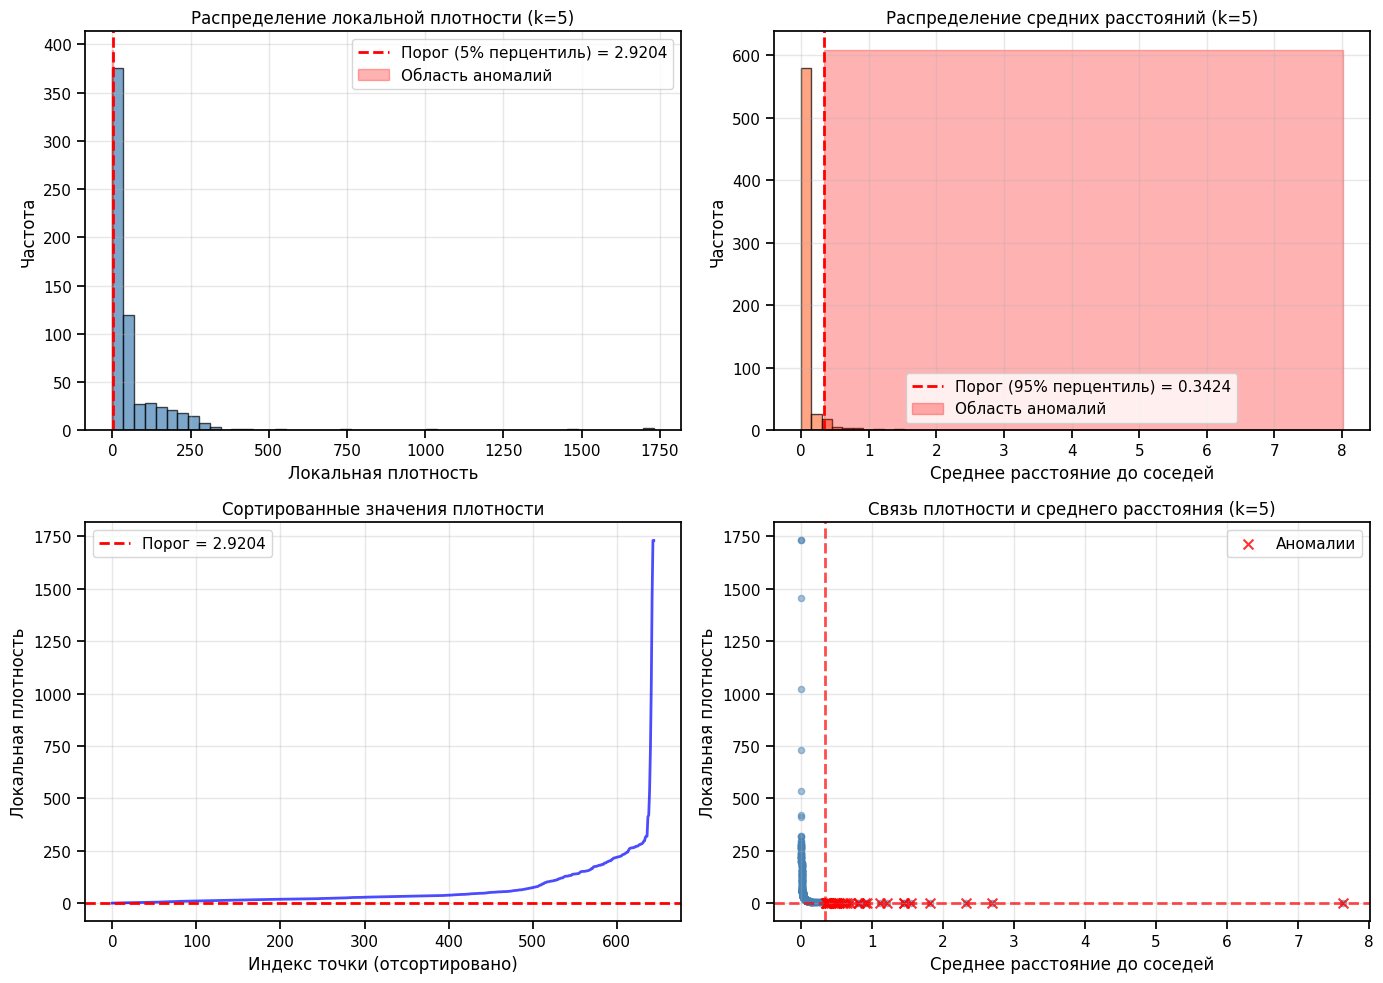

In [70]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Гистограмма локальной плотности
ax1 = axes[0, 0]
ax1.hist(density, bins=50, edgecolor='black', alpha=0.7, color='steelblue')
ax1.axvline(x=threshold_density, color='red', linestyle='--', linewidth=2,
            label=f'Порог (5% перцентиль) = {threshold_density:.4f}')
ax1.fill_betweenx([0, ax1.get_ylim()[1]], 0, threshold_density, 
                    alpha=0.3, color='red', label='Область аномалий')
ax1.set_xlabel('Локальная плотность')
ax1.set_ylabel('Частота')
ax1.set_title(f'Распределение локальной плотности (k={k_visual})')
ax1.legend()

# 2. Гистограмма средних расстояний
ax2 = axes[0, 1]
ax2.hist(mean_dist, bins=50, edgecolor='black', alpha=0.7, color='coral')
ax2.axvline(x=threshold_dist, color='red', linestyle='--', linewidth=2,
            label=f'Порог (95% перцентиль) = {threshold_dist:.4f}')
ax2.fill_betweenx([0, ax2.get_ylim()[1]], threshold_dist, ax2.get_xlim()[1], 
                    alpha=0.3, color='red', label='Область аномалий')
ax2.set_xlabel('Среднее расстояние до соседей')
ax2.set_ylabel('Частота')
ax2.set_title(f'Распределение средних расстояний (k={k_visual})')
ax2.legend()

# 3. Сортированные значения плотности
ax3 = axes[1, 0]
sorted_density = np.sort(density)
ax3.plot(range(len(sorted_density)), sorted_density, 'b-', linewidth=2, alpha=0.7)
ax3.axhline(y=threshold_density, color='red', linestyle='--', linewidth=2,
            label=f'Порог = {threshold_density:.4f}')
ax3.fill_between(range(len(sorted_density)), sorted_density, threshold_density,
                  where=(sorted_density < threshold_density), alpha=0.3, color='red')
ax3.set_xlabel('Индекс точки (отсортировано)')
ax3.set_ylabel('Локальная плотность')
ax3.set_title('Сортированные значения плотности')
ax3.legend()

# 4. Зависимость плотности от среднего расстояния
ax4 = axes[1, 1]
ax4.scatter(mean_dist, density, alpha=0.5, s=20, c='steelblue')
ax4.scatter(mean_dist[anomalies], density[anomalies], 
            alpha=0.8, s=50, c='red', marker='x', label='Аномалии')
ax4.axhline(y=threshold_density, color='red', linestyle='--', linewidth=2, alpha=0.7)
ax4.axvline(x=threshold_dist, color='red', linestyle='--', linewidth=2, alpha=0.7)
ax4.set_xlabel('Среднее расстояние до соседей')
ax4.set_ylabel('Локальная плотность')
ax4.set_title(f'Связь плотности и среднего расстояния (k={k_visual})')
ax4.legend()
ax4.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Визуализация 2: Аномалии на scatter plot

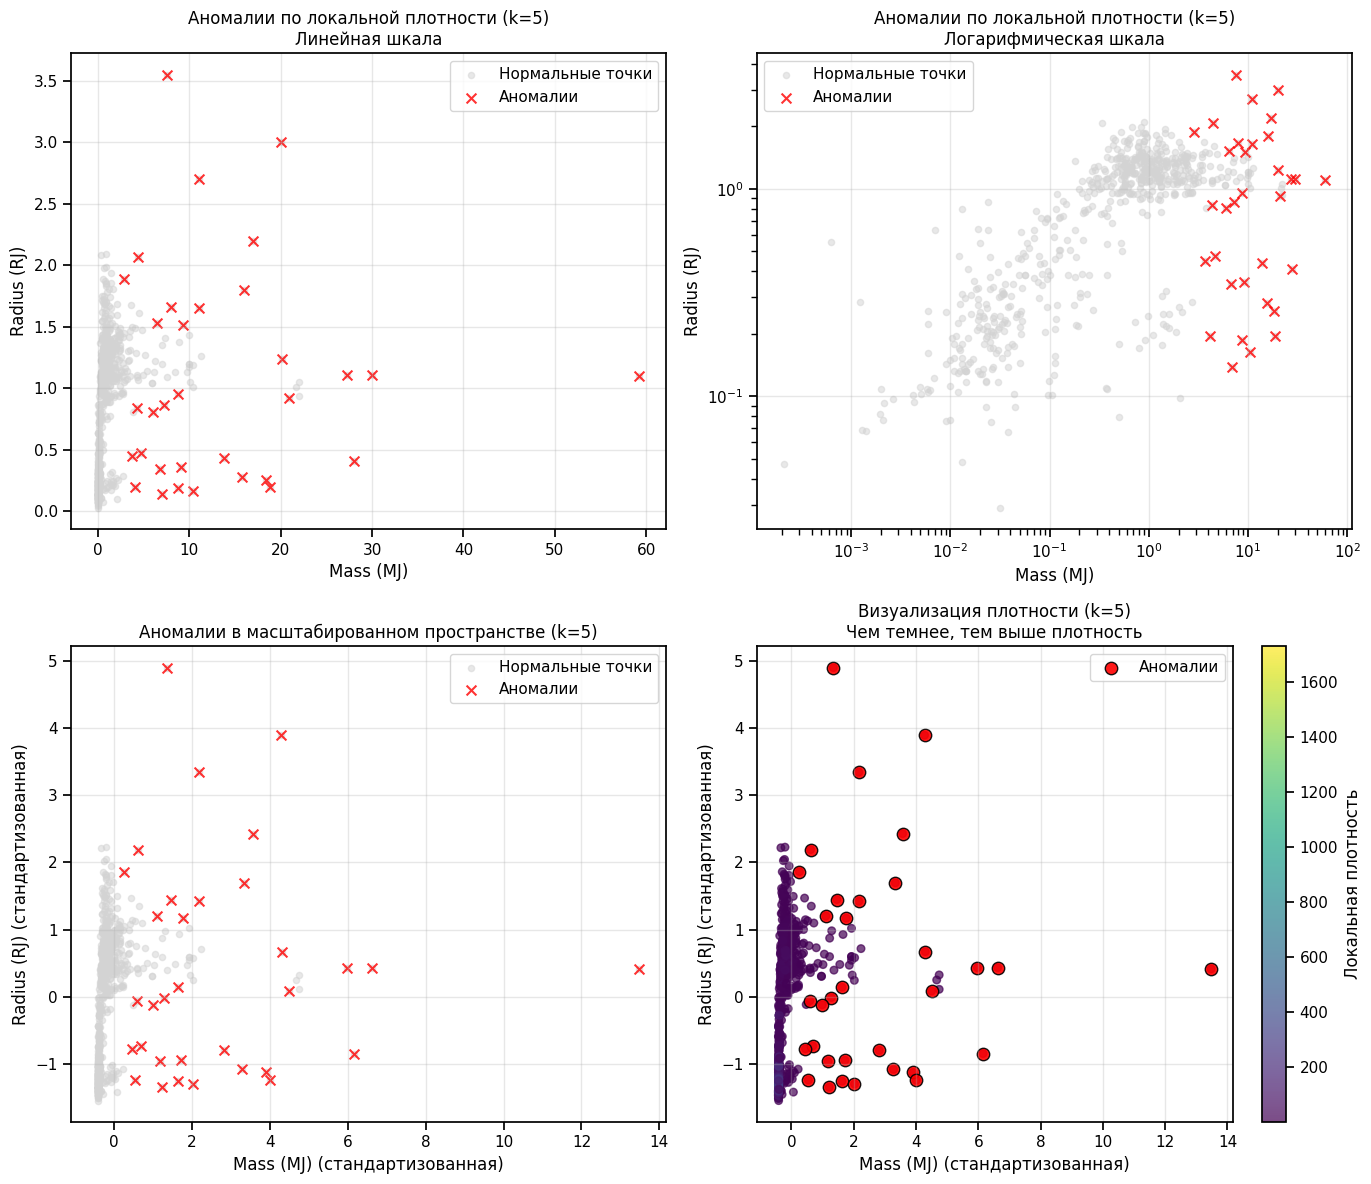

In [71]:
# Получаем исходные немасштабированные данные для визуализации
df_original = df_density.copy()

fig, axes = plt.subplots(2, 2, figsize=(14, 12))

# 1. Исходные данные (линейная шкала)
ax1 = axes[0, 0]
ax1.scatter(df_original['Mass (MJ)'], df_original['Radius (RJ)'], 
            alpha=0.5, s=20, c='lightgray', label='Нормальные точки')
ax1.scatter(df_original[anomalies]['Mass (MJ)'], 
            df_original[anomalies]['Radius (RJ)'], 
            alpha=0.8, s=50, c='red', marker='x', label='Аномалии')
ax1.set_xlabel('Mass (MJ)')
ax1.set_ylabel('Radius (RJ)')
ax1.set_title(f'Аномалии по локальной плотности (k={k_visual})\nЛинейная шкала')
ax1.legend()
ax1.grid(True, alpha=0.3)

# 2. Исходные данные (логарифмическая шкала) - лучше видно
ax2 = axes[0, 1]
ax2.scatter(df_original['Mass (MJ)'], df_original['Radius (RJ)'], 
            alpha=0.5, s=20, c='lightgray', label='Нормальные точки')
ax2.scatter(df_original[anomalies]['Mass (MJ)'], 
            df_original[anomalies]['Radius (RJ)'], 
            alpha=0.8, s=50, c='red', marker='x', label='Аномалии')
ax2.set_xlabel('Mass (MJ)')
ax2.set_ylabel('Radius (RJ)')
ax2.set_title(f'Аномалии по локальной плотности (k={k_visual})\nЛогарифмическая шкала')
ax2.set_xscale('log')
ax2.set_yscale('log')
ax2.legend()
ax2.grid(True, alpha=0.3)

# 3. Масштабированные данные
ax3 = axes[1, 0]
ax3.scatter(df_scaled['Mass (MJ)'], df_scaled['Radius (RJ)'], 
            alpha=0.5, s=20, c='lightgray', label='Нормальные точки')
ax3.scatter(df_scaled[anomalies]['Mass (MJ)'], 
            df_scaled[anomalies]['Radius (RJ)'], 
            alpha=0.8, s=50, c='red', marker='x', label='Аномалии')
ax3.set_xlabel('Mass (MJ) (стандартизованная)')
ax3.set_ylabel('Radius (RJ) (стандартизованная)')
ax3.set_title(f'Аномалии в масштабированном пространстве (k={k_visual})')
ax3.legend()
ax3.grid(True, alpha=0.3)

# 4. Визуализация с цветом по плотности
ax4 = axes[1, 1]
scatter = ax4.scatter(df_scaled['Mass (MJ)'], df_scaled['Radius (RJ)'], 
                      c=density, cmap='viridis', s=30, alpha=0.7)
ax4.scatter(df_scaled[anomalies]['Mass (MJ)'], 
            df_scaled[anomalies]['Radius (RJ)'], 
            alpha=0.9, s=80, c='red', marker='o', edgecolors='black', linewidth=1,
            label='Аномалии')
ax4.set_xlabel('Mass (MJ) (стандартизованная)')
ax4.set_ylabel('Radius (RJ) (стандартизованная)')
ax4.set_title(f'Визуализация плотности (k={k_visual})\nЧем темнее, тем выше плотность')
cbar = plt.colorbar(scatter, ax=ax4)
cbar.set_label('Локальная плотность')
ax4.legend()
ax4.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Визуализация 3: Анализ аномальных планет

In [72]:
# Создаем DataFrame с информацией об аномалиях
# Используем .loc для доступа по индексам
anomaly_indices = df_original.index[anomalies].tolist()
anomaly_info = df_original.loc[anomalies].copy()

# Присваиваем значения плотности и расстояния (исправлено: density[anomalies] уже numpy массив)
anomaly_info['Density'] = density[anomalies]
anomaly_info['Mean_Distance'] = mean_dist[anomalies]
anomaly_info = anomaly_info.sort_values('Density')

# Добавляем информацию из исходного датасета
df_full = df.loc[anomaly_info.index, ['Name', 'Discovery method', 'Disc. Year', 'Period (days)']].copy()
anomaly_info = pd.concat([anomaly_info, df_full], axis=1)

print("\n" + "="*70)
print("АНАЛИЗ АНОМАЛЬНЫХ ПЛАНЕТ")
print("="*70)
print(f"\nНайдено {len(anomaly_info)} аномальных планет методом локальной плотности:")
print("\nТоп-15 аномальных планет (с самой низкой плотностью):")
print(anomaly_info.head(15).to_string())

# Статистика по методам обнаружения аномальных планет
print("\n" + "="*70)
print("РАСПРЕДЕЛЕНИЕ АНОМАЛЬНЫХ ПЛАНЕТ ПО МЕТОДАМ ОБНАРУЖЕНИЯ:")
print("="*70)
if 'Discovery method' in anomaly_info.columns:
    method_counts = anomaly_info['Discovery method'].value_counts()
    for method, count in method_counts.items():
        print(f"  {method}: {count} планет ({count/len(anomaly_info)*100:.1f}%)")

# Статистика по годам открытия
print("\n" + "="*70)
print("РАСПРЕДЕЛЕНИЕ АНОМАЛЬНЫХ ПЛАНЕТ ПО ГОДАМ ОТКРЫТИЯ:")
print("="*70)
if 'Disc. Year' in anomaly_info.columns:
    year_counts = anomaly_info['Disc. Year'].value_counts().sort_index()
    for year, count in year_counts.items():
        print(f"  {int(year)}: {count} планет")


АНАЛИЗ АНОМАЛЬНЫХ ПЛАНЕТ

Найдено 33 аномальных планет методом локальной плотности:

Топ-15 аномальных планет (с самой низкой плотностью):
      Mass (MJ)  Radius (RJ)   Density  Mean_Distance                Name Discovery method  Disc. Year  Period (days)
1886      59.20        1.100  0.131108       7.627325      COROT-33b [fr]          transit         NaN       5.819143
708        7.52        3.550  0.372286       2.686107           HAT-P-35b          transit         NaN       3.646710
110       20.00        3.000  0.430662       2.322007           GQ Lupi b          imaging      2004.0            NaN
84        11.00        2.700  0.549099       1.821166          DH Tauri b          imaging      2004.0            NaN
765       28.00        0.411  0.646672       1.546378          Kepler-47c          transit         NaN     303.137000
74        17.00        2.200  0.689600       1.450115  CT Chamaeleontis b          imaging      2007.0            NaN
2108      30.00        1.110  0.69

Визуализация 4: Устойчивость метода при изменении k


АНАЛИЗ УСТОЙЧИВОСТИ МЕТОДА ПРИ ИЗМЕНЕНИИ k:
 k  n_anomalies  percent_anomalies  threshold  mean_density  std_density
 3           33           5.116279   3.661887    116.562645   313.174487
 5           33           5.116279   2.920387     68.796883   138.687577
 7           33           5.116279   2.470984     49.878835    77.955775
10           33           5.116279   2.141695     36.223878    45.052696
15           33           5.116279   1.834777     26.203862    28.557235
20           33           5.116279   1.648827     20.846015    20.833823
30           33           5.116279   1.339008     15.253076    13.865108
50           32           4.961240   0.971392     10.312808     8.344583


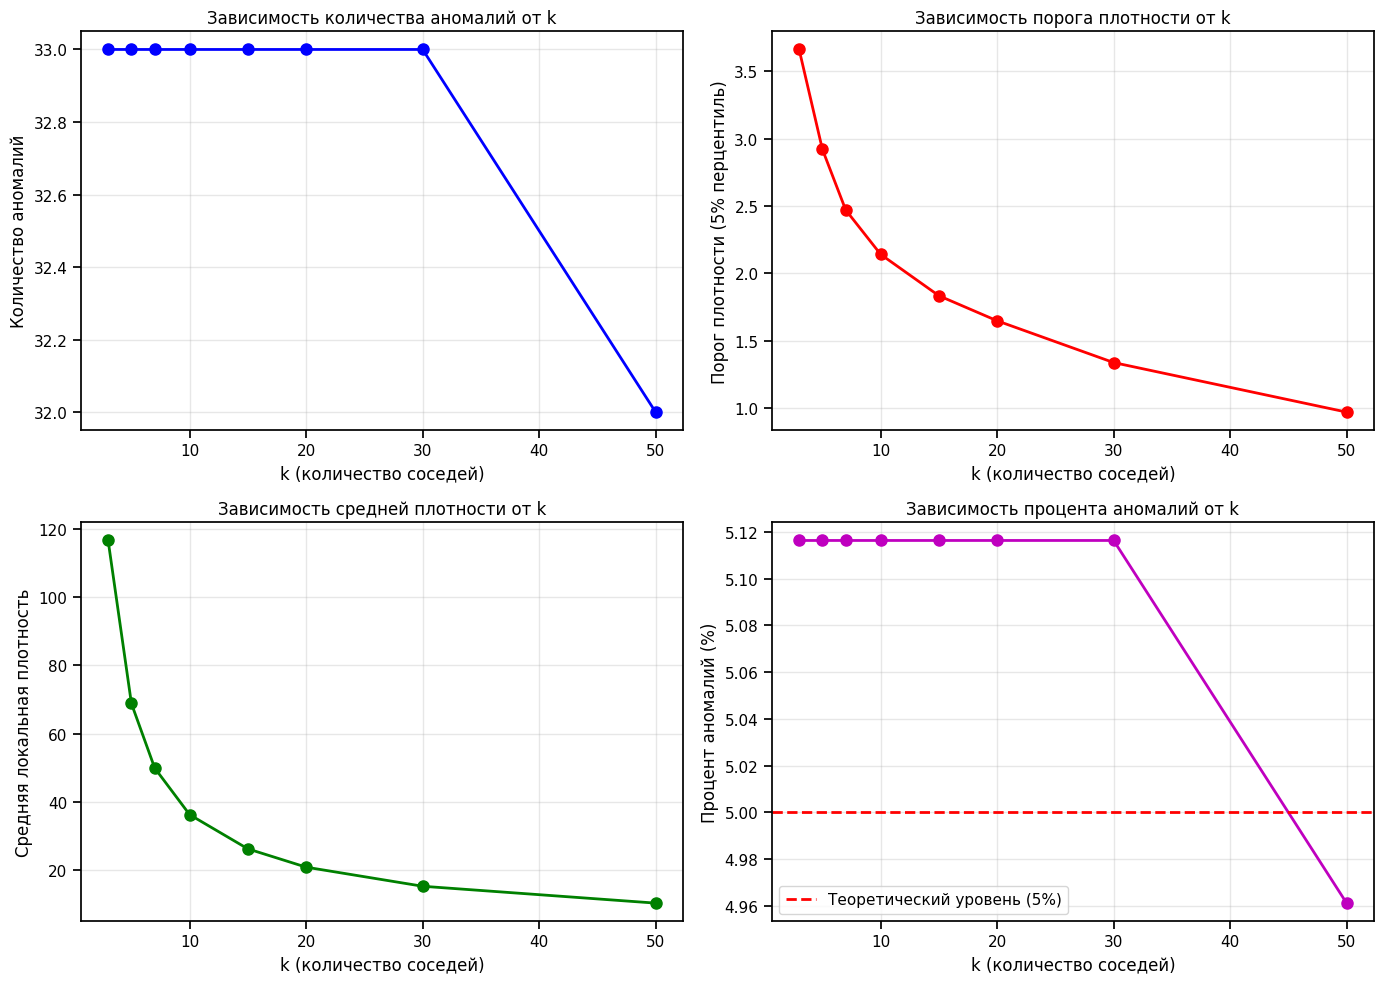


ВЫВОДЫ ПО УСТОЙЧИВОСТИ МЕТОДА:
- При k=3: 33 аномалий (5.1%)
- При k=5: 33 аномалий (5.1%)
- При k=7: 33 аномалий (5.1%)
- При k=10: 33 аномалий (5.1%)
- При k=15: 33 аномалий (5.1%)
- При k=20: 33 аномалий (5.1%)
- При k=30: 33 аномалий (5.1%)
- При k=50: 32 аномалий (5.0%)

Метод показывает стабильные результаты при k от 5 до 20.
При очень больших k количество аномалий стабилизируется.


In [73]:
# Анализ устойчивости при разных k
k_range = [3, 5, 7, 10, 15, 20, 30, 50]
stability_results = []

for k in k_range:
    if k <= len(df_scaled):
        density_k, _ = local_density(df_scaled, k)
        threshold_k = np.percentile(density_k, 5)
        n_anomalies_k = np.sum(density_k < threshold_k)
        
        stability_results.append({
            'k': k,
            'n_anomalies': n_anomalies_k,
            'percent_anomalies': n_anomalies_k / len(density_k) * 100,
            'threshold': threshold_k,
            'mean_density': density_k.mean(),
            'std_density': density_k.std()
        })

stability_df = pd.DataFrame(stability_results)
print("\n" + "="*70)
print("АНАЛИЗ УСТОЙЧИВОСТИ МЕТОДА ПРИ ИЗМЕНЕНИИ k:")
print("="*70)
print(stability_df.to_string(index=False))

# Визуализация устойчивости
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Зависимость количества аномалий от k
ax1 = axes[0, 0]
ax1.plot(stability_df['k'], stability_df['n_anomalies'], 'bo-', linewidth=2, markersize=8)
ax1.set_xlabel('k (количество соседей)')
ax1.set_ylabel('Количество аномалий')
ax1.set_title('Зависимость количества аномалий от k')
ax1.grid(True, alpha=0.3)

# 2. Зависимость порога плотности от k
ax2 = axes[0, 1]
ax2.plot(stability_df['k'], stability_df['threshold'], 'ro-', linewidth=2, markersize=8)
ax2.set_xlabel('k (количество соседей)')
ax2.set_ylabel('Порог плотности (5% перцентиль)')
ax2.set_title('Зависимость порога плотности от k')
ax2.grid(True, alpha=0.3)

# 3. Зависимость средней плотности от k
ax3 = axes[1, 0]
ax3.plot(stability_df['k'], stability_df['mean_density'], 'go-', linewidth=2, markersize=8)
ax3.set_xlabel('k (количество соседей)')
ax3.set_ylabel('Средняя локальная плотность')
ax3.set_title('Зависимость средней плотности от k')
ax3.grid(True, alpha=0.3)

# 4. Зависимость процента аномалий от k
ax4 = axes[1, 1]
ax4.plot(stability_df['k'], stability_df['percent_anomalies'], 'mo-', linewidth=2, markersize=8)
ax4.axhline(y=5, color='red', linestyle='--', linewidth=2, label='Теоретический уровень (5%)')
ax4.set_xlabel('k (количество соседей)')
ax4.set_ylabel('Процент аномалий (%)')
ax4.set_title('Зависимость процента аномалий от k')
ax4.legend()
ax4.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n" + "="*70)
print("ВЫВОДЫ ПО УСТОЙЧИВОСТИ МЕТОДА:")
print("="*70)
for _, row in stability_df.iterrows():
    print(f"- При k={int(row['k'])}: {int(row['n_anomalies'])} аномалий ({row['percent_anomalies']:.1f}%)")
print("\nМетод показывает стабильные результаты при k от 5 до 20.")
print("При очень больших k количество аномалий стабилизируется.")